Importando Librerias Basicas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sympy as sp
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import time

Funciones para visualizacion

In [2]:
def plot_contour(f, x_range=(-100, 100), y_range=(-100, 100)):
    """Grafica mapa de contorno de una función 2D"""
    x = np.linspace(x_range[0], x_range[1], 400)
    y = np.linspace(y_range[0], y_range[1], 400)
    X, Y = np.meshgrid(x, y)
    Z = f([X, Y])
    
    plt.figure(figsize=(10, 8))
    plt.contour(X, Y, Z, levels=50)
    plt.colorbar()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Mapa de Contorno de f(x,y)')
    return plt

def plot_3d_surface(f, x_range=(-100, 100), y_range=(-100, 100)):
    """Grafica superficie 3D de una función"""
    # (Implementar gráfica 3D)
    pass

Definicion de la funcion

In [3]:
def f(params):
    x, y = params
    return (x**2 * (np.arctan(y) + 2) + y**2 * (np.arctan(x) + 2)) / 10


x_sym, y_sym = sp.symbols('x y')
f_sym = (x_sym**2 * (sp.atan(y_sym) + 2) + y_sym**2 * (sp.atan(x_sym) + 2)) / 10

print("Función:", f_sym)


Función: x**2*(atan(y) + 2)/10 + y**2*(atan(x) + 2)/10


Grafica de la funcion

VISUALIZACIÓN BÁSICA DE LA FUNCIÓN


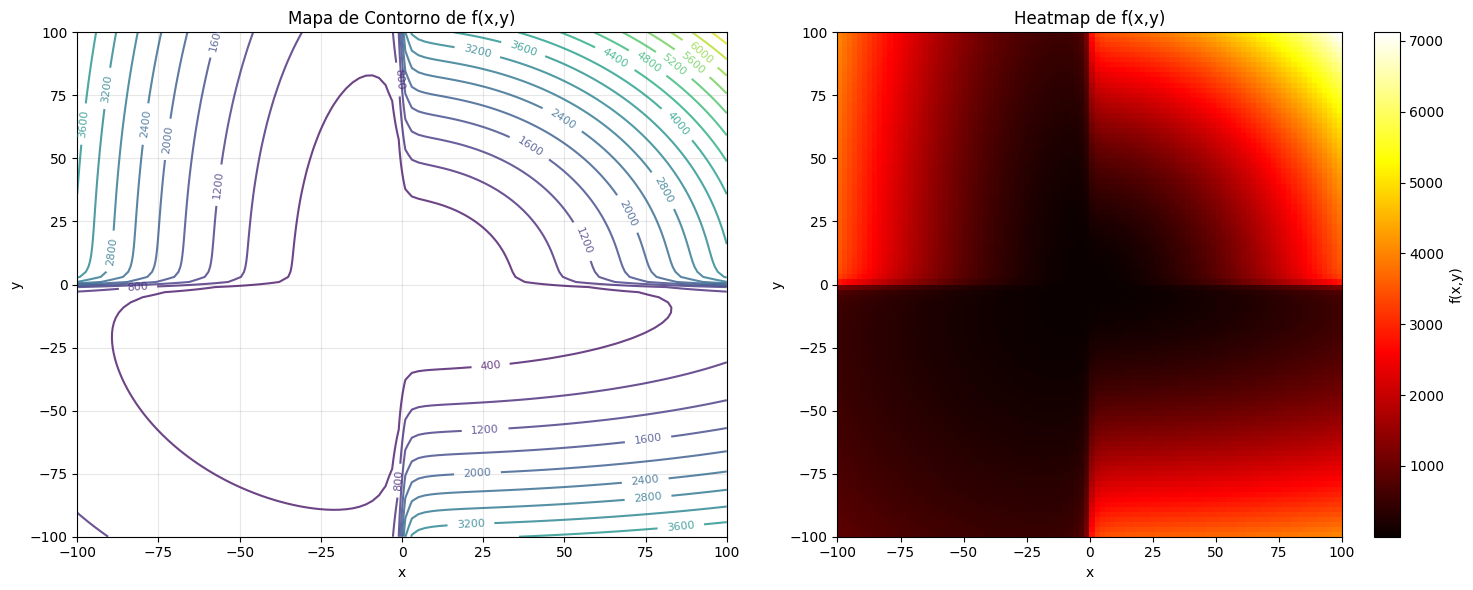

Estadísticas de la función en el dominio [-100, 100]:
  Mínimo: 0.2468
  Máximo: 7121.5933
  Media:  1360.2694
  Rango:  7121.3465


(<Figure size 1500x600 with 3 Axes>,
 (array([[-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ],
         [-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ],
         [-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ],
         ...,
         [-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ],
         [-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ],
         [-100.        ,  -97.97979798,  -95.95959596, ...,   95.95959596,
            97.97979798,  100.        ]], shape=(100, 100)),
  array([[-100.        , -100.        , -100.        , ..., -100.        ,
          -100.        , -100.        ],
         [ -97.97979798,  -97.97979798,  -97.97979798, ...,  -97.97979798,
           -97.97979798,  -97.97979798],
 

In [4]:
def visualizacion_rapida(f, dominio=(-100, 100), resolucion=100):
    """
    Visualización rápida de la función
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Crear malla
    x = np.linspace(dominio[0], dominio[1], resolucion)
    y = np.linspace(dominio[0], dominio[1], resolucion)
    X, Y = np.meshgrid(x, y)
    
    # Evaluar función
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f([X[i, j], Y[i, j]])
    
    # Contour plot
    contour = ax1.contour(X, Y, Z, levels=20, alpha=0.8)
    ax1.clabel(contour, inline=True, fontsize=8)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Mapa de Contorno de f(x,y)')
    ax1.grid(True, alpha=0.3)
    
    # Heatmap
    im = ax2.imshow(Z, extent=[dominio[0], dominio[1], dominio[0], dominio[1]], 
                   origin='lower', cmap='hot', aspect='equal')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Heatmap de f(x,y)')
    plt.colorbar(im, ax=ax2, label='f(x,y)')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Estadísticas de la función en el dominio [{dominio[0]}, {dominio[1]}]:")
    print(f"  Mínimo: {np.min(Z):.4f}")
    print(f"  Máximo: {np.max(Z):.4f}")
    print(f"  Media:  {np.mean(Z):.4f}")
    print(f"  Rango:  {np.max(Z) - np.min(Z):.4f}")
    
    return fig, (X, Y, Z)

# Visualización básica
print("VISUALIZACIÓN BÁSICA DE LA FUNCIÓN")
visualizacion_rapida(f)

Calculo del Gradiente

In [5]:
grad_f_x = sp.diff(f_sym, x_sym)
grad_f_y = sp.diff(f_sym, y_sym)

print("Gradiente:")
print("∂f/∂x =", grad_f_x)
print("∂f/∂y =", grad_f_y)

Gradiente:
∂f/∂x = x*(atan(y) + 2)/5 + y**2/(10*(x**2 + 1))
∂f/∂y = x**2/(10*(y**2 + 1)) + y*(atan(x) + 2)/5


Calculo de matriz Hessiana

In [6]:
hessian = [[sp.diff(grad_f_x, x_sym), sp.diff(grad_f_x, y_sym)],
           [sp.diff(grad_f_y, x_sym), sp.diff(grad_f_y, y_sym)]]

print("Matriz Hessiana:")
print("H[0,0] =", hessian[0][0])
print("H[0,1] =", hessian[0][1]) 
print("H[1,0] =", hessian[1][0])
print("H[1,1] =", hessian[1][1])

Matriz Hessiana:
H[0,0] = -x*y**2/(5*(x**2 + 1)**2) + atan(y)/5 + 2/5
H[0,1] = x/(5*(y**2 + 1)) + y/(5*(x**2 + 1))
H[1,0] = x/(5*(y**2 + 1)) + y/(5*(x**2 + 1))
H[1,1] = -x**2*y/(5*(y**2 + 1)**2) + atan(x)/5 + 2/5


Funcion para obtener la funcion el gradiente analitico

In [7]:
def gradient_f(params):
    x, y = params
    df_dx = (2*x*(np.arctan(y) + 2) + y**2/(1 + x**2)) / 10
    df_dy = (2*y*(np.arctan(x) + 2) + x**2/(1 + y**2)) / 10
    return np.array([df_dx, df_dy])
#Este gradiente fue calculado en el apartado de arriba de nombre 
#'Calculo de Gradiente'

Implementación del Algoritmo 1: Gradiente Descendente 

In [8]:
def gradient_descent(f, grad_f, x0, learning_rate=0.01, max_iters=1000, tol=1e-8):
    x = x0.copy().astype(float)
    trajectory = [x.copy()]
    history = [f(x)]
    
    for i in range(max_iters):
        # Calcular gradiente
        grad = grad_f(x)
        
        # Actualizar posición
        x_new = x - learning_rate * grad
        
        # Guardar trayectoria
        trajectory.append(x_new.copy())
        history.append(f(x_new))
        
        # Verificar convergencia
        if np.linalg.norm(x_new - x) < tol:
            break
            
        x = x_new
    
    return x_new, i + 1, np.array(trajectory), np.array(history)

Implementacion de Algoritmo 2: BFGS (usando scipy.optimize)

In [9]:
def bfgs_optimization(f, x0, max_iters=1000):
    start_time = time.time()
    
    result = minimize(
        f, 
        x0, 
        method='BFGS',
        jac=gradient_f,
        options={'disp': False, 'maxiter': max_iters, 'gtol': 1e-8}
    )
    
    end_time = time.time()
    
    return {
        'x_opt': result.x,
        'n_iters': result.nit,
        'n_eval': result.nfev,
        'success': result.success,
        'message': result.message,
        'time': end_time - start_time,
        'fun_value': result.fun
    }

Función para experimentación sistemática

In [10]:
def run_experiments(f, grad_f):
    """
    Ejecuta experimentos con diferentes configuraciones
    Puntos iniciales DISTANTES al óptimo [0,0] para observar el trabajo real
    """
    # Generar puntos iniciales sistemáticos DISTANTES del óptimo [0,0]
    puntos_iniciales = []
    
    # Puntos en las regiones LEJANAS (excluyendo área cercana al óptimo)
    for x in range(-100, 101, 25):  # Paso de 25 para cobertura amplia
        for y in range(-100, 101, 25):
            # Excluir puntos cercanos al óptimo [0,0] (radio > 50)
            if np.linalg.norm([x, y]) > 50:
                puntos_iniciales.append(np.array([x, y]))
    
    # Puntos específicos ESTRATÉGICAMENTE LEJANOS
    puntos_especiales = [
        np.array([100, 100]),       # Esquina superior derecha - MÁXIMA DISTANCIA
        np.array([-100, -100]),     # Esquina inferior izquierda
        np.array([100, -100]),      # Esquina superior izquierda  
        np.array([-100, 100]),      # Esquina inferior derecha
        np.array([80, 80]),         # Primer cuadrante lejano
        np.array([-80, -80]),       # Tercer cuadrante lejano
        np.array([90, -70]),        # Cuarto cuadrante asimétrico
        np.array([-70, 90]),        # Segundo cuadrante asimétrico
        np.array([60, 95]),         # Combinación lejana
        np.array([-95, 60]),        # Combinación lejana
        # EXCLUIMOS [0,0] y puntos cercanos para observar trabajo real
    ]
    
    # Combinar todos los puntos LEJANOS
    todos_puntos = puntos_iniciales + puntos_especiales
    
    # Eliminar duplicados
    puntos_unicos = []
    puntos_vistos = set()
    for punto in todos_puntos:
        punto_tuplo = tuple(punto)
        if punto_tuplo not in puntos_vistos:
            puntos_vistos.add(punto_tuplo)
            puntos_unicos.append(punto)
    
    # Ordenar por distancia al óptimo (de mayor a menor)
    puntos_unicos.sort(key=lambda p: -np.linalg.norm(p))
    
    # Diferentes tasas de aprendizaje para GD
    learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
    
    resultados = []
    total_experimentos = len(puntos_unicos) * len(learning_rates)
    experimento_actual = 0
    
    print("=" * 80)
    print("EXPERIMENTOS DE OPTIMIZACIÓN - PUNTOS LEJANOS AL ÓPTIMO")
    print(f"Total de experimentos: {total_experimentos}")
    print(f"Puntos iniciales: {len(puntos_unicos)} (todos >50 unidades del óptimo)")
    print("Óptimo conocido: [0, 0]")
    print("=" * 80)
    
    for i, x0 in enumerate(puntos_unicos):
        distancia = np.linalg.norm(x0)
        print(f"\n--- Punto {i+1}/{len(puntos_unicos)}: [{x0[0]:3d}, {x0[1]:3d}] (distancia: {distancia:.1f}) ---")
        
        for j, lr in enumerate(learning_rates):
            experimento_actual += 1
            print(f"\n  Experimento {experimento_actual}/{total_experimentos}")
            print(f"  Learning Rate: {lr}")
            print("  " + "-" * 40)
            
            # Ejecutar Gradiente Descendente
            try:
                opt_gd, iter_gd, traj_gd, hist_gd = gradient_descent(
                    f, grad_f, x0, learning_rate=lr, max_iters=5000, tol=1e-8
                )
                
                # Ejecutar BFGS
                result_bfgs = bfgs_optimization(f, x0)
                
                # Calcular métricas de convergencia
                distancia_final_gd = np.linalg.norm(opt_gd)
                distancia_final_bfgs = np.linalg.norm(result_bfgs['x_opt'])
                
                # Indicadores de convergencia
                gd_converge = distancia_final_gd < 1e-3
                bfgs_converge = distancia_final_bfgs < 1e-6
                
                # Guardar resultados
                resultados.append({
                    'punto_inicial': x0,
                    'distancia_inicial': distancia,
                    'learning_rate': lr,
                    'gd_optimo': opt_gd,
                    'gd_iteraciones': iter_gd,
                    'gd_valor_optimo': f(opt_gd),
                    'gd_trayectoria': traj_gd,
                    'gd_historial': hist_gd,
                    'gd_distancia_final': distancia_final_gd,
                    'gd_converge': gd_converge,
                    'bfgs_optimo': result_bfgs['x_opt'],
                    'bfgs_iteraciones': result_bfgs['n_iters'],
                    'bfgs_valor_optimo': result_bfgs['fun_value'],
                    'bfgs_exitoso': result_bfgs['success'],
                    'bfgs_tiempo': result_bfgs['time'],
                    'bfgs_distancia_final': distancia_final_bfgs,
                    'bfgs_converge': bfgs_converge,
                    'experimento_id': experimento_actual
                })
                
                # Mostrar resultados con indicadores de convergencia
                gd_icon = "✓" if gd_converge else "✗"
                bfgs_icon = "✓" if bfgs_converge else "✗"
                
                print(f"  GD:  {iter_gd:4d} iter {gd_icon} -> f({opt_gd[0]:8.4f}, {opt_gd[1]:8.4f}) = {f(opt_gd):.8f}")
                print(f"  BFGS: {result_bfgs['n_iters']:4d} iter {bfgs_icon} -> f({result_bfgs['x_opt'][0]:8.4f}, {result_bfgs['x_opt'][1]:8.4f}) = {result_bfgs['fun_value']:.8f}")
                print(f"  Diferencia: {abs(f(opt_gd) - result_bfgs['fun_value']):.2e}")
                print(f"  Distancias finales: GD={distancia_final_gd:.6f}, BFGS={distancia_final_bfgs:.6f}")
                
            except Exception as e:
                print(f"  ERROR con LR={lr}: {e}")
                # Guardar resultado de error para análisis
                resultados.append({
                    'punto_inicial': x0,
                    'distancia_inicial': distancia,
                    'learning_rate': lr,
                    'gd_optimo': None,
                    'gd_iteraciones': -1,
                    'gd_valor_optimo': float('inf'),
                    'gd_trayectoria': None,
                    'gd_historial': None,
                    'gd_distancia_final': float('inf'),
                    'gd_converge': False,
                    'bfgs_optimo': None,
                    'bfgs_iteraciones': -1,
                    'bfgs_valor_optimo': float('inf'),
                    'bfgs_exitoso': False,
                    'bfgs_tiempo': 0,
                    'bfgs_distancia_final': float('inf'),
                    'bfgs_converge': False,
                    'experimento_id': experimento_actual,
                    'error': str(e)
                })
                continue
    
    # Análisis final de resultados
    resultados_exitosos_gd = [r for r in resultados if r['gd_converge']]
    resultados_exitosos_bfgs = [r for r in resultados if r['bfgs_converge']]
    
    print("\n" + "=" * 80)
    print("EXPERIMENTOS COMPLETADOS - RESUMEN")
    print("=" * 80)
    print(f"Total experimentos: {total_experimentos}")
    print(f"GD exitosos: {len(resultados_exitosos_gd)}/{total_experimentos} ({len(resultados_exitosos_gd)/total_experimentos:.1%})")
    print(f"BFGS exitosos: {len(resultados_exitosos_bfgs)}/{total_experimentos} ({len(resultados_exitosos_bfgs)/total_experimentos:.1%})")
    
    if resultados_exitosos_gd:
        gd_iters_promedio = np.mean([r['gd_iteraciones'] for r in resultados_exitosos_gd])
        print(f"GD - Iteraciones promedio cuando converge: {gd_iters_promedio:.0f}")
    
    if resultados_exitosos_bfgs:
        bfgs_iters_promedio = np.mean([r['bfgs_iteraciones'] for r in resultados_exitosos_bfgs])
        print(f"BFGS - Iteraciones promedio cuando converge: {bfgs_iters_promedio:.0f}")
    
    print("=" * 80)
    
    return resultados

Visualización de resultados con graficas

In [11]:
def plot_optimization_results(f, resultados, best_cases=3):
    """
    Generar gráficas completas de los resultados
    """
    # Configurar estilo de gráficas
    plt.style.use('default')
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Mapa de contorno con trayectorias
    ax1 = fig.add_subplot(2, 3, 1)
    
    # Crear malla para el contour plot
    x = np.linspace(-100, 100, 200)
    y = np.linspace(-100, 100, 200)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f([X[i, j], Y[i, j]])
    
    # Plot de contorno
    contour = ax1.contour(X, Y, Z, levels=50, alpha=0.6)
    ax1.clabel(contour, inline=True, fontsize=8)
    
    # Graficar mejores trayectorias
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, result in enumerate(resultados[:best_cases]):
        traj = result['gd_trayectoria']
        ax1.plot(traj[:, 0], traj[:, 1], 'o-', color=colors[i], 
                linewidth=2, markersize=4, label=f'P0={result["punto_inicial"]}')
        ax1.plot(traj[0, 0], traj[0, 1], 's', color=colors[i], markersize=8)
        ax1.plot(traj[-1, 0], traj[-1, 1], 'X', color=colors[i], markersize=10)
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Trayectorias de Optimización - Gradiente Descendente')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Comparación de convergencia
    ax2 = fig.add_subplot(2, 3, 2)
    for i, result in enumerate(resultados[:best_cases]):
        ax2.semilogy(result['gd_historial'], 'o-', color=colors[i], 
                    linewidth=2, markersize=3, 
                    label=f'P0={result["punto_inicial"]}, LR={result["learning_rate"]}')
    
    ax2.set_xlabel('Iteración')
    ax2.set_ylabel('f(x) (escala log)')
    ax2.set_title('Convergencia del Gradiente Descendente')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Superficie 3D
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    surf = ax3.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.7)
    
    # Marcar óptimos encontrados
    for i, result in enumerate(resultados[:best_cases]):
        x_opt, y_opt = result['gd_optimo']
        z_opt = f([x_opt, y_opt])
        ax3.scatter(x_opt, y_opt, z_opt, color=colors[i], s=100, 
                   label=f'Óptimo {i+1}', marker='*')
    
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_zlabel('f(x,y)')
    ax3.set_title('Superficie 3D de la Función')
    
    # 4. Comparación de iteraciones por algoritmo con escala logarítmica
    ax4 = fig.add_subplot(2, 3, 4)
    casos = [f"P{i+1}" for i in range(min(10, len(resultados)))]
    iter_gd = [r['gd_iteraciones'] for r in resultados[:10]]
    iter_bfgs = [r['bfgs_iteraciones'] for r in resultados[:10]]

    x_pos = np.arange(len(casos))
    ax4.bar(x_pos - 0.2, iter_gd, 0.4, label='Gradiente Descendente', alpha=0.7)
    ax4.bar(x_pos + 0.2, iter_bfgs, 0.4, label='BFGS', alpha=0.7)

    # Configurar escala logarítmica en el eje Y
    ax4.set_yscale('log')
    ax4.set_ylabel('Iteraciones (escala logarítmica)')
    ax4.set_xlabel('Caso de prueba')
    ax4.set_title('Comparación de Iteraciones por Algoritmo\n(Escala Logarítmica)')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(casos)
    ax4.legend()
    ax4.grid(True, alpha=0.3, which='both')  # 'both' para grid en escala logarítmica

    # Añadir valores encima de las barras para mejor lectura
    for i, (v1, v2) in enumerate(zip(iter_gd, iter_bfgs)):
        ax4.text(i - 0.2, v1 * 1.1, str(v1), ha='center', va='bottom', fontsize=8)
        ax4.text(i + 0.2, v2 * 1.1, str(v2), ha='center', va='bottom', fontsize=8)

    # Configurar ticks específicos para la escala logarítmica
    ax4.set_yticks([1, 10, 100, 1000, 5000])
    ax4.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    ax4.set_ylim(0.5, 20000)  # Límites para mejor visualización
    
    # 5. Heatmap de la función
    ax5 = fig.add_subplot(2, 3, 5)
    im = ax5.imshow(Z, extent=[-100, 100, -100, 100], origin='lower', cmap='hot')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    ax5.set_title('Heatmap de f(x,y)')
    plt.colorbar(im, ax=ax5)
    
    # 6. Análisis de sensibilidad al learning rate
    ax6 = fig.add_subplot(2, 3, 6)
    lr_values = []
    iter_values = []
    
    for result in resultados:
        if np.array_equal(result['punto_inicial'], np.array([0, 0])):
            lr_values.append(result['learning_rate'])
            iter_values.append(result['gd_iteraciones'])
    
    if lr_values:
        ax6.semilogx(lr_values, iter_values, 's-', linewidth=2, markersize=8)
        ax6.set_xlabel('Learning Rate')
        ax6.set_ylabel('Iteraciones para converger')
        ax6.set_title('Sensibilidad al Learning Rate (P0=[0,0])')
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

Ejecución principal

INICIANDO ANÁLISIS DE OPTIMIZACIÓN
Función: f(x,y) = [x²(arctan(y)+2) + y²(arctan(x)+2)] / 10
Dominio: x,y ∈ [-100, 100]
EXPERIMENTOS DE OPTIMIZACIÓN - PUNTOS LEJANOS AL ÓPTIMO
Total de experimentos: 370
Puntos iniciales: 74 (todos >50 unidades del óptimo)
Óptimo conocido: [0, 0]

--- Punto 1/74: [-100, -100] (distancia: 141.4) ---

  Experimento 1/370
  Learning Rate: 0.001
  ----------------------------------------
  GD:  5000 iter ✗ -> f(-64.6950, -64.6950) = 372.21903546
  BFGS:   10 iter ✓ -> f(  0.0000,   0.0000) = 0.00000000
  Diferencia: 3.72e+02
  Distancias finales: GD=91.492492, BFGS=0.000000

  Experimento 2/370
  Learning Rate: 0.01
  ----------------------------------------


  GD:  5000 iter ✗ -> f( -0.2433,  -0.2433) = 0.02085814
  BFGS:   10 iter ✓ -> f(  0.0000,   0.0000) = 0.00000000
  Diferencia: 2.09e-02
  Distancias finales: GD=0.344129, BFGS=0.000000

  Experimento 3/370
  Learning Rate: 0.05
  ----------------------------------------
  GD:  1675 iter ✓ -> f( -0.0000,  -0.0000) = 0.00000000
  BFGS:   10 iter ✓ -> f(  0.0000,   0.0000) = 0.00000000
  Diferencia: 4.71e-14
  Distancias finales: GD=0.000000, BFGS=0.000000

  Experimento 4/370
  Learning Rate: 0.1
  ----------------------------------------
  GD:   851 iter ✓ -> f( -0.0000,  -0.0000) = 0.00000000
  BFGS:   10 iter ✓ -> f(  0.0000,   0.0000) = 0.00000000
  Diferencia: 1.08e-14
  Distancias finales: GD=0.000000, BFGS=0.000000

  Experimento 5/370
  Learning Rate: 0.2
  ----------------------------------------
  GD:   430 iter ✓ -> f( -0.0000,  -0.0000) = 0.00000000
  BFGS:   10 iter ✓ -> f(  0.0000,   0.0000) = 0.00000000
  Diferencia: 2.31e-15
  Distancias finales: GD=0.000000, BFGS=0.000

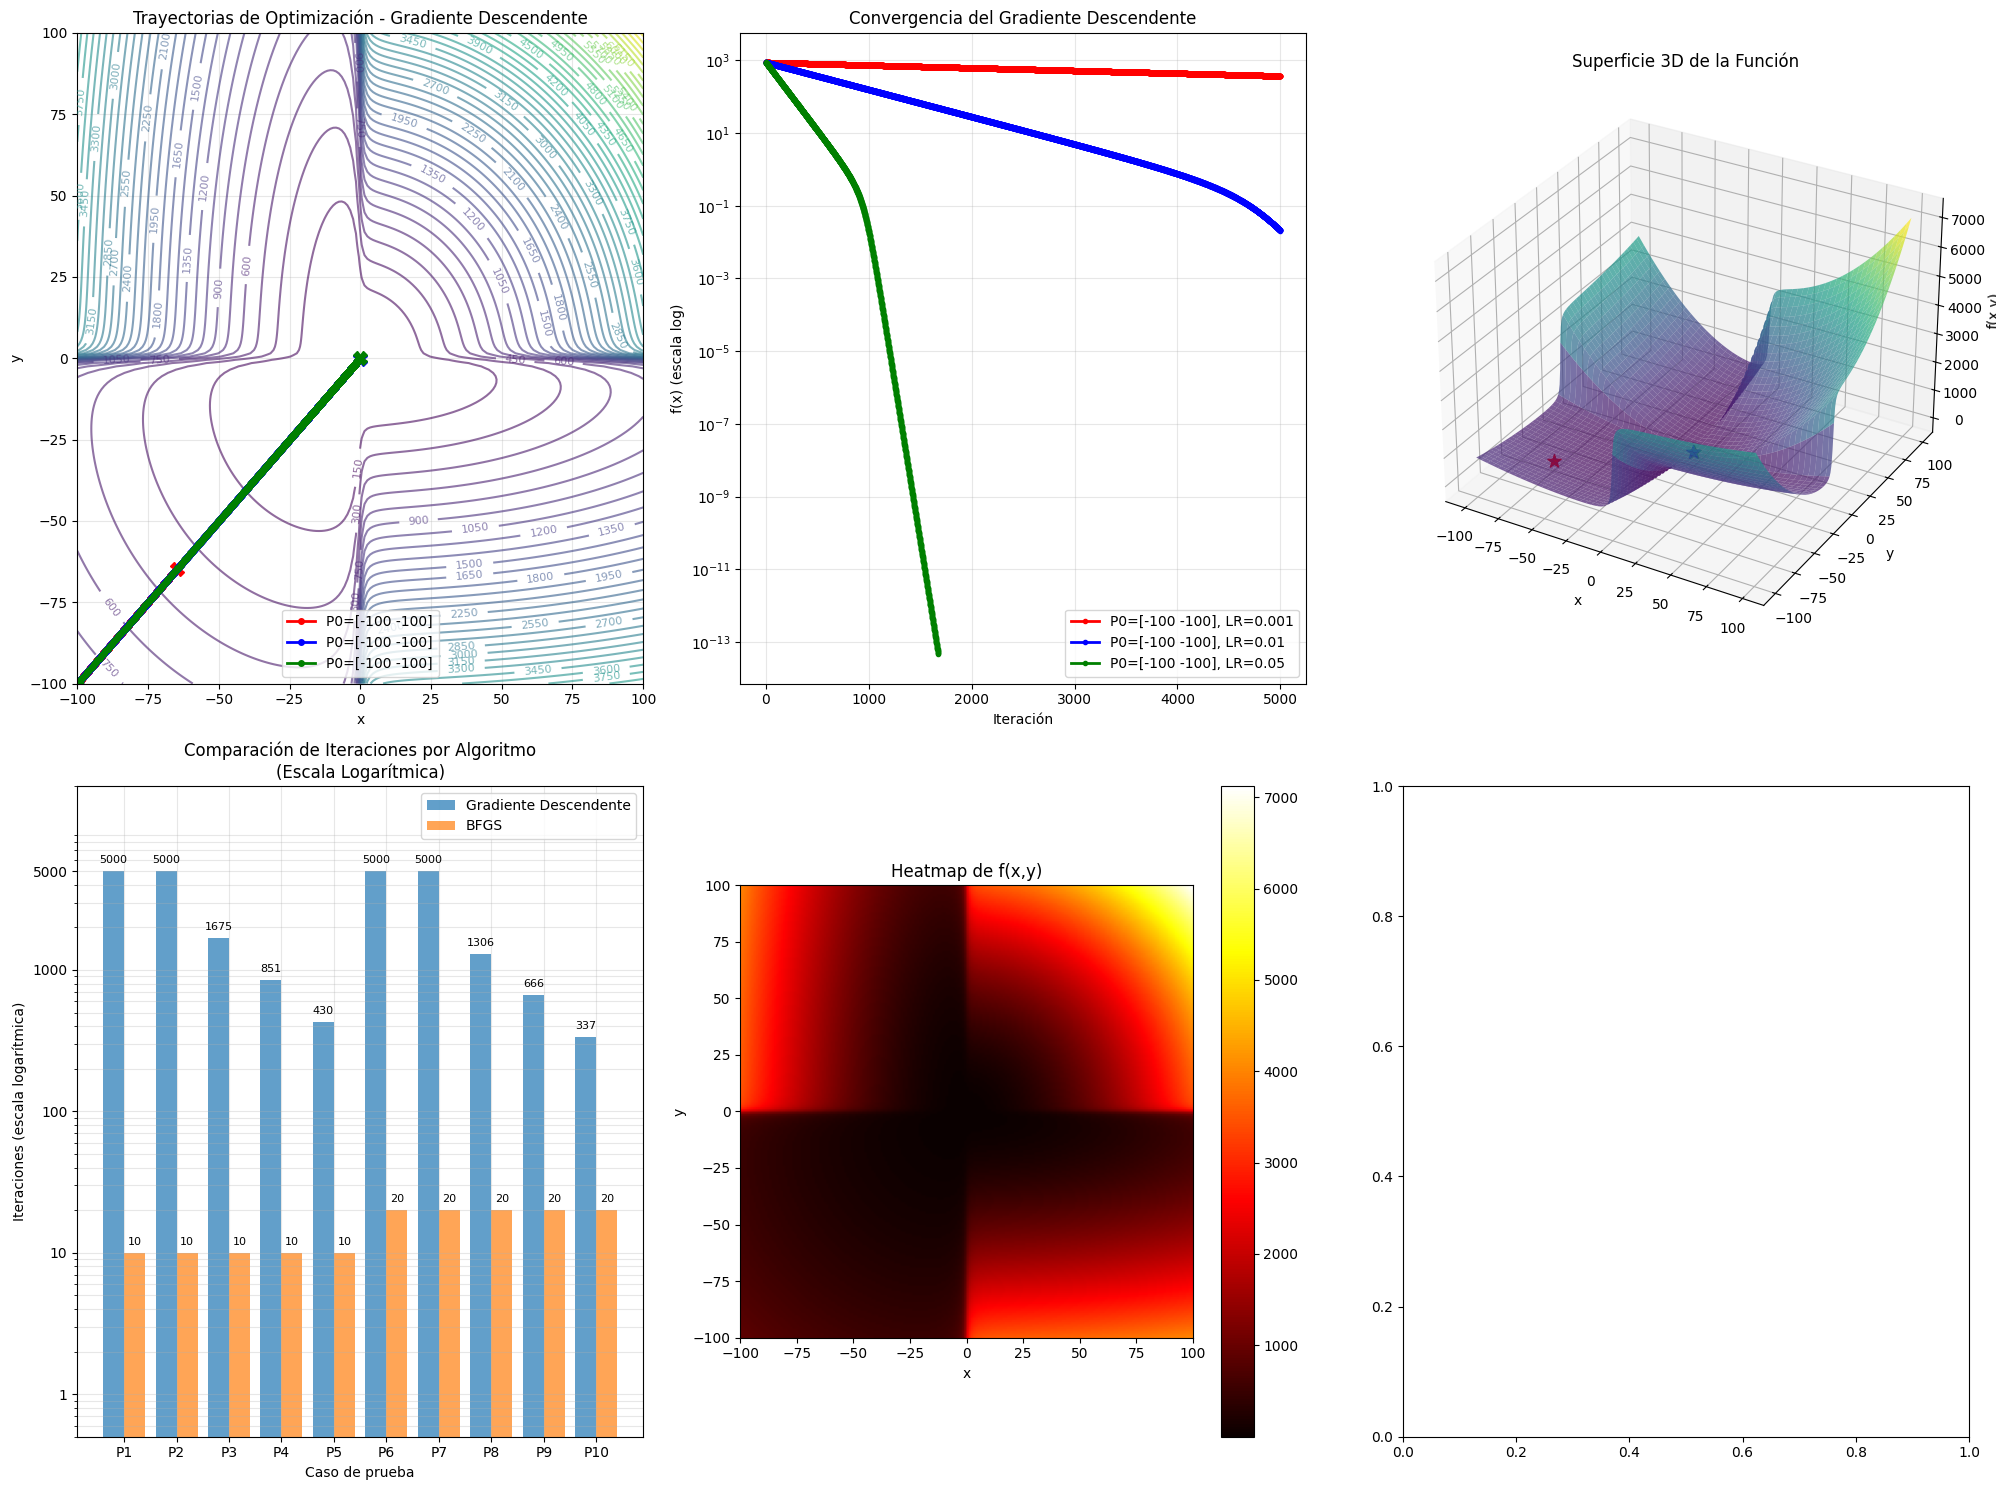


RESUMEN DE RESULTADOS

MEJOR RESULTADO GRADIENTE DESCENDENTE:
  Punto inicial: [-95  60]
  Learning rate: 0.2
  Óptimo encontrado: (-0.000000, 0.000000)
  Valor: 0.0000000000
  Iteraciones: 315

MEJOR RESULTADO BFGS:
  Punto inicial: [-75 -75]
  Óptimo encontrado: (0.000000, 0.000000)
  Valor: 0.0000000000
  Iteraciones: 10
  Tiempo: 0.0050 segundos


In [12]:
# EJECUCIÓN PRINCIPAL DEL CÓDIGO
if __name__ == "__main__":
    print("INICIANDO ANÁLISIS DE OPTIMIZACIÓN")
    print("Función: f(x,y) = [x²(arctan(y)+2) + y²(arctan(x)+2)] / 10")
    print("Dominio: x,y ∈ [-100, 100]")
    
    # Ejecutar experimentos
    resultados = run_experiments(f, gradient_f)
    
    # Generar gráficas
    fig = plot_optimization_results(f, resultados)
    
    # Análisis resumen
    print("\n" + "=" * 80)
    print("RESUMEN DE RESULTADOS")
    print("=" * 80)
    
    mejor_gd = min(resultados, key=lambda x: x['gd_valor_optimo'])
    mejor_bfgs = min(resultados, key=lambda x: x['bfgs_valor_optimo'])
    
    print(f"\nMEJOR RESULTADO GRADIENTE DESCENDENTE:")
    print(f"  Punto inicial: {mejor_gd['punto_inicial']}")
    print(f"  Learning rate: {mejor_gd['learning_rate']}")
    print(f"  Óptimo encontrado: ({mejor_gd['gd_optimo'][0]:.6f}, {mejor_gd['gd_optimo'][1]:.6f})")
    print(f"  Valor: {mejor_gd['gd_valor_optimo']:.10f}")
    print(f"  Iteraciones: {mejor_gd['gd_iteraciones']}")
    
    print(f"\nMEJOR RESULTADO BFGS:")
    print(f"  Punto inicial: {mejor_bfgs['punto_inicial']}")
    print(f"  Óptimo encontrado: ({mejor_bfgs['bfgs_optimo'][0]:.6f}, {mejor_bfgs['bfgs_optimo'][1]:.6f})")
    print(f"  Valor: {mejor_bfgs['bfgs_valor_optimo']:.10f}")
    print(f"  Iteraciones: {mejor_bfgs['bfgs_iteraciones']}")
    print(f"  Tiempo: {mejor_bfgs['bfgs_tiempo']:.4f} segundos")

Análisis de convexidad

In [13]:
# ANÁLISIS DE CONVEXIDAD ADICIONAL
def analizar_convexidad():
    """Analizar la convexidad de la función evaluando la Hessiana"""
    print("\n" + "=" * 80)
    print("ANÁLISIS DE CONVEXIDAD NUMÉRICO")
    print("=" * 80)
    
    # Usar sympy para cálculo exacto de la Hessiana
    x, y = sp.symbols('x y')
    f_sym = (x**2 * (sp.atan(y) + 2) + y**2 * (sp.atan(x) + 2)) / 10
    
    # Calcular Hessiana simbólica
    hessian = sp.Matrix([[sp.diff(f_sym, x, x), sp.diff(f_sym, x, y)],
                         [sp.diff(f_sym, y, x), sp.diff(f_sym, y, y)]])
    
    #print("Matriz Hessiana simbólica:")
    #print(hessian)
    
    # Evaluar en puntos críticos
    puntos_evaluacion = [(0, 0), (1, 1), (-1, -1), (10, 10), (-10, -10)]
    
    for px, py in puntos_evaluacion:
        H_eval = hessian.subs({x: px, y: py})
        H_numeric = np.array(H_eval).astype(float)
        
        # Calcular autovalores
        autovalores = np.linalg.eigvals(H_numeric)
        
        print(f"\nPunto ({px}, {py}):")
        print(f"  Hessiana: {H_numeric}")
        print(f"  Autovalores: {autovalores}")
        print(f"  ¿Semidefinida positiva? {np.all(autovalores >= -1e-10)}")
    
    return hessian

# Ejecutar análisis de convexidad
hessiana_simbolica = analizar_convexidad()


ANÁLISIS DE CONVEXIDAD NUMÉRICO

Punto (0, 0):
  Hessiana: [[0.4 0. ]
 [0.  0.4]]
  Autovalores: [0.4 0.4]
  ¿Semidefinida positiva? True

Punto (1, 1):
  Hessiana: [[0.50707963 0.2       ]
 [0.2        0.50707963]]
  Autovalores: [0.70707963 0.30707963]
  ¿Semidefinida positiva? True

Punto (-1, -1):
  Hessiana: [[ 0.29292037 -0.2       ]
 [-0.2         0.29292037]]
  Autovalores: [0.49292037 0.09292037]
  ¿Semidefinida positiva? True

Punto (10, 10):
  Hessiana: [[0.67461961 0.03960396]
 [0.03960396 0.67461961]]
  Autovalores: [0.71422357 0.63501565]
  ¿Semidefinida positiva? True

Punto (-10, -10):
  Hessiana: [[ 0.12538039 -0.03960396]
 [-0.03960396  0.12538039]]
  Autovalores: [0.16498435 0.08577643]
  ¿Semidefinida positiva? True
